# Task 4: Regression Analysis

### 1. Dataset Selection

#### The dataset is loaded.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv("house_prices.csv")  
print(df.head())

  House_ID  Location  Size  Number_of_Rooms  Number_of_Bathrooms  Year  \
0     H001  Suburban   847                2                    1  2000   
1     H002     Urban  3586                2                    2  1984   
2     H003     Urban  3752                4                    1  1982   
3     H004     Urban  1269                2                    1  2022   
4     H005     Rural  3592                6                    2  1999   

   Distance  Nearby_Amenities   Price  
0      39.5                12  156851  
1      30.7                 3  781059  
2      16.8                14  860004  
3      22.6                 8  366232  
4      34.1                15  941597  


#### Missing values are checked to determine if any preprocessing is required. This ensures the dataset is clean before further analysis.

In [3]:
print(df.info())  
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   House_ID             100 non-null    object 
 1   Location             100 non-null    object 
 2   Size                 100 non-null    int64  
 3   Number_of_Rooms      100 non-null    int64  
 4   Number_of_Bathrooms  100 non-null    int64  
 5   Year                 100 non-null    int64  
 6   Distance             100 non-null    float64
 7   Nearby_Amenities     100 non-null    int64  
 8   Price                100 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 7.2+ KB
None
House_ID               0
Location               0
Size                   0
Number_of_Rooms        0
Number_of_Bathrooms    0
Year                   0
Distance               0
Nearby_Amenities       0
Price                  0
dtype: int64


In [4]:
print(df.columns)

Index(['House_ID', 'Location', 'Size', 'Number_of_Rooms',
       'Number_of_Bathrooms', 'Year', 'Distance', 'Nearby_Amenities', 'Price'],
      dtype='object')


## 2. Load and Explore

#### The median is used to fill in numerical missing values, and the mode is used to fill in categorical ones. This ensures that the dataset is full and does not bias the distributions.

In [6]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

#### To see the distributions of numerical columns, histograms are plotted. This makes it easier to spot trends, skewness, and any outliers in the data.

array([[<AxesSubplot:title={'center':'Size'}>,
        <AxesSubplot:title={'center':'Number_of_Rooms'}>,
        <AxesSubplot:title={'center':'Number_of_Bathrooms'}>],
       [<AxesSubplot:title={'center':'Year'}>,
        <AxesSubplot:title={'center':'Distance'}>,
        <AxesSubplot:title={'center':'Nearby_Amenities'}>],
       [<AxesSubplot:title={'center':'Price'}>, <AxesSubplot:>,
        <AxesSubplot:>]], dtype=object)

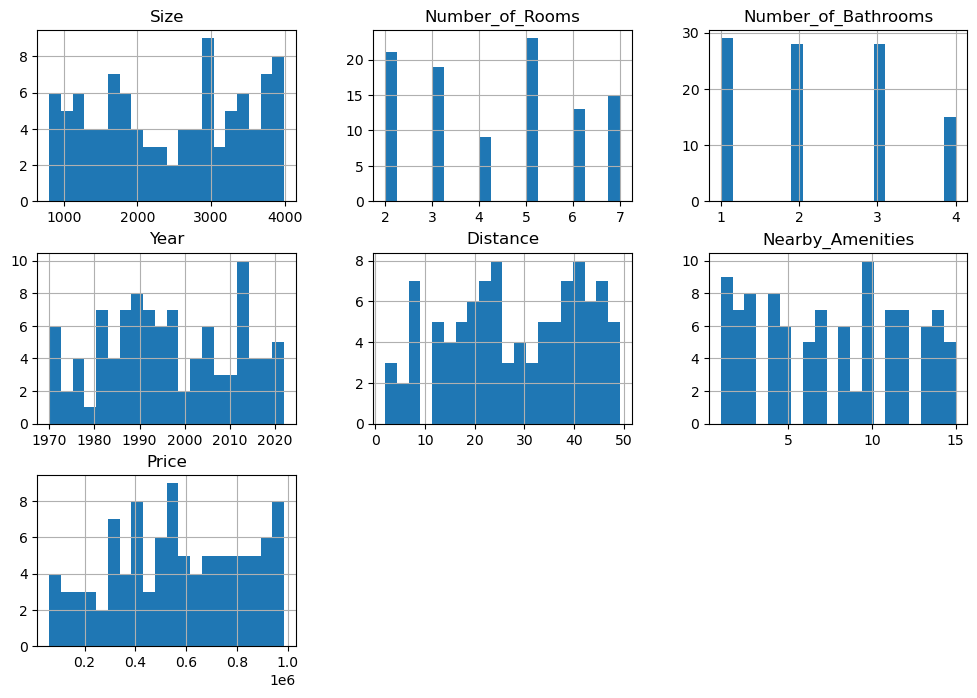

In [7]:
numerical_cols = ["Size", "Number_of_Rooms", "Number_of_Bathrooms", "Year", "Distance", "Nearby_Amenities", "Price"]
df[numerical_cols].hist(figsize=(12, 8), bins=20, layout=(3, 3))

#### A boxplot is used to identify outliers and explain value distributions across numerical features. It visualizes data distribution, core tendency, and extreme values.

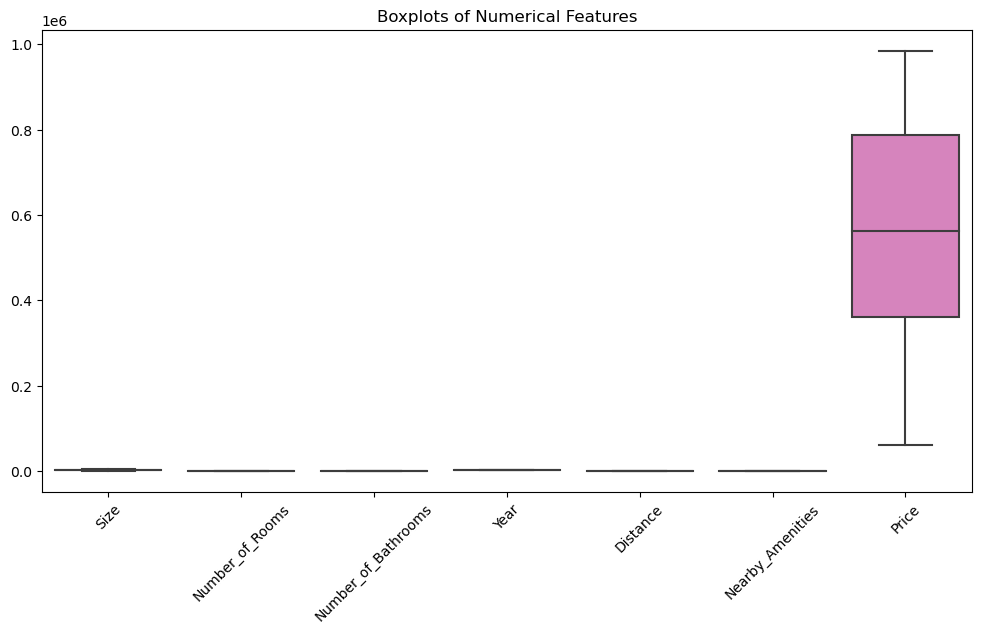

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

## 3. Data Preprocessing

#### Numerical features are scaled using Min-Max to bring values into a comparable range. One-hot encoding converts the category Location column to numerical data for machine learning models. This assures standardized inputs, which improves model performance.

In [10]:
df = df.drop(columns=["House_ID"])

In [11]:
import warnings
warnings.filterwarnings("ignore")

scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [13]:
encoder = OneHotEncoder(drop="first", sparse=False)
location_encoded = encoder.fit_transform(df[["Location"]])
location_df = pd.DataFrame(location_encoded, columns=encoder.get_feature_names_out(["Location"]))

## 4. Feature Selection

#### The encoded location data is merged back in, replacing the original column. A correlation heatmap is created to examine the correlations between features and highlight highly associated variables. This facilitates feature selection for model training.

In [14]:
df = pd.concat([df.drop(columns=["Location"]), location_df], axis=1)
correlation_matrix = df.corr()

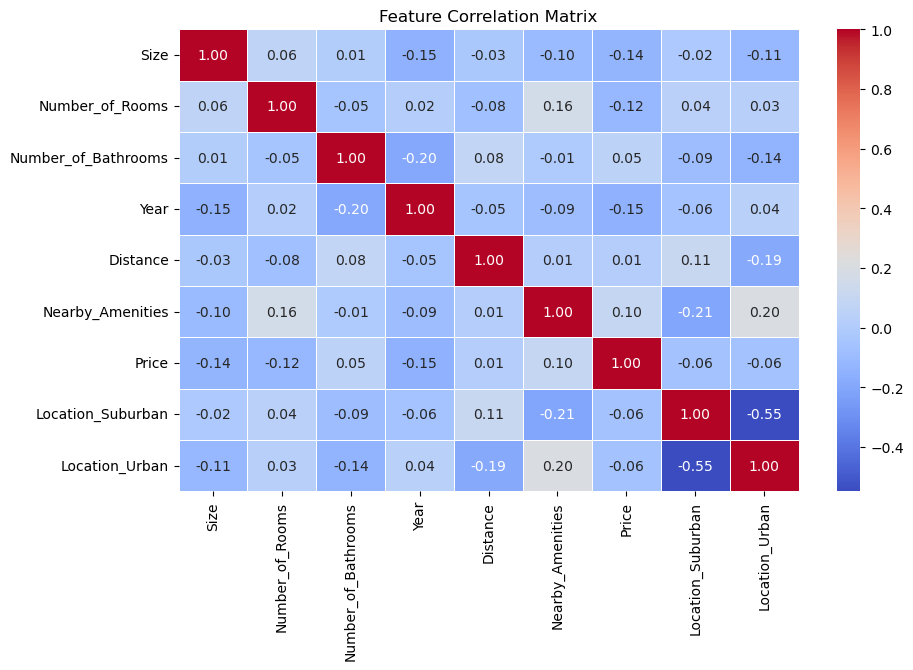

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
correlation_with_price = correlation_matrix["Price"].abs().sort_values(ascending=False)
print("Feature correlations with Price:\n", correlation_with_price)

Feature correlations with Price:
 Price                  1.000000
Year                   0.146335
Size                   0.135278
Number_of_Rooms        0.117910
Nearby_Amenities       0.098023
Location_Urban         0.064550
Location_Suburban      0.060499
Number_of_Bathrooms    0.054774
Distance               0.014981
Name: Price, dtype: float64


## 5. Model Training and Evaluation

In [17]:
X = df.drop(columns=["Price"])
y = df["Price"]

#### The dataset is split into training (80%) and testing (20%) sets to ensure proper model evaluation. 
#### A linear regression model is then trained on the training data to learn relationships between features and the target variable.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

In [20]:
print(f"Linear Regression - RMSE: {rmse:.4f}, R²: {r2:.4f}")

Linear Regression - RMSE: 0.3221, R²: -0.0160
